# Задача №1. KNN: «iPhone или Android?»

**Постановка:** по ответам на короткую анкету научить ИИ прогнозировать разновидность телефона респондента (iPhone / Android) методом **k ближайших соседей**.

**Требования из задания:**
- подготовка исходных данных;
- обучение модели KNN;
- **анализ — какое k лучше?**;
- тестирование;
- показ решения, code review.

**Команда:** 3–4 человека (парное программирование).

| Роль | Имя |
|---|---|
| Подготовка данных | _заполнить_ |
| Моделирование (KNN) | _заполнить_ |
| Анализ и тестирование | _заполнить_ |
| Показ решения | _заполнить_ |


In [1]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, auc, classification_report,
                             ConfusionMatrixDisplay, confusion_matrix,
                             roc_curve)
from sklearn.model_selection import (LeaveOneOut, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
print('Окружение: OK')

Окружение: OK


## 1. Загрузка и осмотр данных

Файл: `ИСИТ_1_практика_Ответы_на_форму_1.csv` — ответы на анкету (44 респондента, 18 столбцов).

In [2]:
def _find_data() -> Path:
    name = 'ИСИТ_1_практика_Ответы_на_форму_1.csv'
    for cand in (Path.cwd() / name,
                 Path.cwd() / ('../../' + name),
                 Path.cwd() / ('../../../' + name),
                 Path('/home/ipetrichenko/mirea-ai') / name):
        if cand.exists():
            return cand
    raise FileNotFoundError(name)

df = pd.read_csv(_find_data())
df.head()

,Отметка времени,"Как вы себя чувствуете, когда оказались в центре внимания в малознакомой компании?",Как чаще всего принимаются ваши повседневные решения о покупках?,"Покупая сложную технику или мебель, какой подход вам ближе?",Что вы выберете при покупке повседневной вещи?,Быстро ли твой телефон разряжается?,Ты часто снимаешь на телефон фото/видео?,"При выборе предмета интерьера или одежды, что станет решающим фактором?",Часто ли твой телефон тормозит/лагает?,"Тебе важно, чтобы все приложения со временем работали одинаково?",Любите ли вы путешествовать?,"Как часто ты меняешь смартфон на новый? Введите число лет (целое, например: 2)","Как часто вы играете в видеоигры? Введите примерное кол-во часов в неделю (целое, например: 5)",Часто ли вы публикуете фотографии или видео в социальных сетях?,Часто ли вы смотрите фильмы и сериалы на телефоне?,"Цвет глаз? (С большой буквы в именительном падеже единственное число, например: Зеленый)","Ближайшая станция метро? (Точное название, например: Преображенская площадь, Сокольники и т.п.)",У тебя айфон или андроид?
0,11.09.2026 20:01:26,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Нет,"Дизайн, эстетика",Нет,Да,Да,4,5,Нет,Да,Зеленый,Юго-западная,Айфон
1,11.09.2026 20:01:27,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Да,"Долговечность, польза",Нет,Да,Да,3,1,Да,Да,Карий,Бульвар Дмитрия Донского,Айфон
2,11.09.2026 20:01:38,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Что-то популярное,Нет,Да,"Дизайн, эстетика",Нет,Да,Да,3,1,Нет,Нет,Карий,Братиславская,Айфон
3,11.09.2026 20:01:41,Дискомфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Нет,"Долговечность, польза",Нет,Да,Да,3,0,Нет,Нет,Серый,Авиамоторная,Айфон
4,11.09.2026 20:02:11,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Что-то популярное,Да,Нет,"Долговечность, польза",Да,Да,Да,4,6,Нет,Нет,Зеленый,Волжская,Андроид


In [3]:
print('Размер выборки:', df.shape)
print('Пропуски:', int(df.isna().sum().sum()))
print('Полные дубликаты строк:', int(df.duplicated().sum()))
print()
print('Целевая переменная:')
print(df['У тебя айфон или андроид?'].value_counts())

Размер выборки: (44, 18)
Пропуски: 0
Полные дубликаты строк: 0

Целевая переменная:
У тебя айфон или андроид?
Андроид    28
Айфон      16
Name: count, dtype: int64


## 2. Подготовка данных

**Отбрасываем (не несут информации для прогноза):**
- `Отметка времени` — момент заполнения формы;
- `Цвет глаз?` — не связан с выбором телефона;
- `Ближайшая станция метро?` — 39 разных значений, почти уникальны на человека: у KNN по этому признаку не будет «соседей», модель начнёт заучивать шум.

**Кодирование:**
- категориальные — one-hot;
- числовые — стандартизация (среднее 0, ст. откл. 1). Для KNN это важно: евклидово расстояние учитывает масштаб, и без стандартизации числовые признаки с большим размахом «затмили» бы категориальные.

Целевая: `1` — iPhone, `0` — Android.

In [4]:
target_col = 'У тебя айфон или андроид?'
noise_mask = df.columns.str.contains('Отметка|Цвет глаз|станция метро')
noise_cols = [c for c, m in zip(df.columns, noise_mask) if bool(m)]
print('Отбрасываем:')
for c in noise_cols:
    print(' -', c)

feature_cols = [c for c in df.columns if c != target_col and c not in noise_cols]
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]
print()
print('Численные:', num_cols)
print('Категорических:', len(cat_cols))

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = ohe.fit_transform(df[cat_cols])
X_num = StandardScaler().fit_transform(df[num_cols])

X = np.hstack([X_cat, X_num])
y = (df[target_col] == 'Айфон').astype(int)   # 1 — iPhone, 0 — Android
print()
print('X (все признаки):', X.shape, '| Доля iPhone:', round(float(y.mean()), 3))

Отбрасываем:
 - Отметка времени
 - Цвет глаз? (С большой буквы в именительном падеже единственное число, например: Зеленый)
 - Ближайшая станция метро? (Точное название, например: Преображенская площадь, Сокольники и т.п.)

Численные: ['Как часто ты меняешь смартфон на новый? Введите число лет (целое, например: 2)', 'Как часто вы играете в видеоигры? Введите примерное кол-во часов в неделю (целое, например: 5)']
Категорических: 12

X (все признаки): (44, 26) | Доля iPhone: 0.364


## 3. KNN по всем признакам: какое k лучше?

Выборка мала (n = 44), поэтому используем **LOOCV** (Leave-One-Out Cross-Validation): каждая запись по одному разу становится «тестовой», и каждое k оценивается на 44 экспериментах — наименее смещённая оценка для малых выборок. Дополнительно — **5-фолдовый стратифицированный CV** как проверка устойчивости.

In [5]:
ks = list(range(1, 16))
loo = LeaveOneOut()
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def sweep(Xm, ks=ks, label=''):
    rows = []
    for k in ks:
        a_loo = cross_val_score(KNeighborsClassifier(n_neighbors=k), Xm, y, cv=loo)
        a_cv5 = cross_val_score(KNeighborsClassifier(n_neighbors=k), Xm, y, cv=skf5)
        rows.append({'k': k,
                     'loo_acc': a_loo.mean(), 'loo_std': a_loo.std(),
                     'cv5_acc': a_cv5.mean(), 'cv5_std': a_cv5.std()})
    return pd.DataFrame(rows).round(4)

res = sweep(X)
res

,k,loo_acc,loo_std,cv5_acc,cv5_std
0,1,0.3636,0.4810,0.5028,0.1428
1,2,0.5682,0.4953,0.6333,0.1388
2,3,0.5227,0.4995,0.5500,0.1495
3,4,0.5909,0.4917,0.5917,0.0461
4,5,0.5227,0.4995,0.5028,0.0747
5,6,0.5682,0.4953,0.5472,0.0911
6,7,0.5455,0.4979,0.5722,0.0988
7,8,0.6136,0.4869,0.5694,0.0756
8,9,0.5682,0.4953,0.5694,0.0756
9,10,0.5455,0.4979,0.6167,0.1060


KNN по ВСЕМ признакам: лучшая LOO-точность 0.614, выбираем k = 4


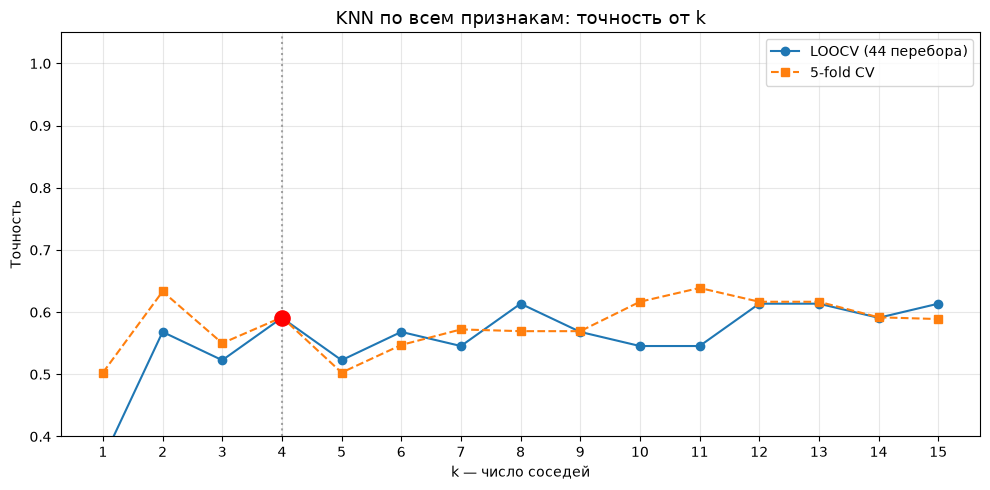

In [6]:
def pick_best(tab):
    max_acc = float(tab['loo_acc'].max())
    stable = tab[tab['loo_acc'] >= max_acc - 0.03]
    return int(stable['k'].min()), max_acc

best_k, max_acc_full = pick_best(res)
print(f'KNN по ВСЕМ признакам: лучшая LOO-точность {max_acc_full:.3f}, выбираем k = {best_k}')

plt.figure(figsize=(10, 5))
plt.plot(res['k'], res['loo_acc'], 'o-', label='LOOCV (44 перебора)')
plt.plot(res['k'], res['cv5_acc'], 's--', label='5-fold CV')
plt.axvline(best_k, color='gray', ls=':', alpha=.7)
plt.scatter([best_k], [float(res.loc[res['k'] == best_k, 'loo_acc'].iloc[0])],
            s=120, zorder=5, color='red')
plt.xlabel('k — число соседей')
plt.ylabel('Точность')
plt.title('KNN по всем признакам: точность от k')
plt.xticks(ks)
plt.ylim(0.4, 1.05)
plt.grid(alpha=.3)
plt.legend()
plt.tight_layout()
plt.show()

### База для сравнения: «все — Android»

Классы несбалансированы (28 Android / 16 iPhone), поэтому тривиальная модель «всегда отвечать Android» уже даёт 28/44 = 0.636. Любая модель KNN должна его превосходить, иначе признакам можно не верить.

Проблема: **26 признаков при 44 образцах** — проклятие размерности. В высокомерном пространстве все точки примерно одинаково далеко друг от друга, «соседей» по факту не существует, голосование сводится к случайности. Проверим это на единичном анализе: какие вопросы анкеты вообще связаны с ответом?

In [7]:
base = float((y == 0).mean())
hits_full = int(round(max_acc_full * len(y)))
bt_full = stats.binomtest(hits_full, len(y), base, alternative='greater')
print(f'Базовая модель (всегда «Андроид»): {base:.3f}')
print(f'Лучший KNN по всем признакам:      {max_acc_full:.3f}  ({hits_full}/{len(y)})')
print(f'Биномиальный тест против базы:     p = {bt_full.pvalue:.3f} (не лучше базы)')

Базовая модель (всегда «Андроид»): 0.636
Лучший KNN по всем признакам:      0.614  (27/44)
Биномиальный тест против базы:     p = 0.685 (не лучше базы)


## 4. Какие вопросы анкеты связаны с типом телефона?

Для каждого признака — связь с целевой переменной:
- числовые: корреляция Пирсона с двумерной (point-biserial) + t-критерий Уэлча;
- категориальные из 2 уровней: phi-коэффициент (chi-square).

Отбираем признаки с наименьшими p-value.

In [8]:
rows = []
for c in feature_cols:
    if pd.api.types.is_numeric_dtype(df[c]):
        r, p = stats.pointbiserialr(y, df[c])
        rows.append({'feature': c, 'тип': 'числовой', 'связь': float(r), 'p': p})
    else:
        tab = pd.crosstab(df[c].astype(str), df[target_col])
        chi2, p, _, _ = stats.chi2_contingency(tab)
        if tab.shape[0] == 2:
            assoc = float(np.sqrt(chi2 / len(df)))
        else:
            assoc = float(np.sqrt(chi2 / (len(df) * (min(tab.shape) - 1))))
        rows.append({'feature': c, 'тип': 'категорный', 'связь': assoc, 'p': p})

uni = pd.DataFrame(rows).sort_values('p').reset_index(drop=True)
uni_disp = uni.copy()
uni_disp['feature'] = uni_disp['feature'].str.slice(0, 62)
uni_disp[['feature', 'тип', 'связь', 'p']] = uni_disp[['feature', 'тип', 'связь', 'p']].round(3)
uni_disp

,feature,тип,связь,p
0,Как часто вы играете в видеоигры? Введите прим...,числовой,-0.298,0.049
1,"Покупая сложную технику или мебель, какой подх...",категорный,0.260,0.084
2,Любите ли вы путешествовать?,категорный,0.241,0.110
3,"Тебе важно, чтобы все приложения со временем р...",категорный,0.232,0.125
4,"При выборе предмета интерьера или одежды, что ...",категорный,0.121,0.424
5,Часто ли вы публикуете фотографии или видео в ...,категорный,0.101,0.501
6,Как часто ты меняешь смартфон на новый? Введит...,числовой,-0.098,0.528
7,Быстро ли твой телефон разряжается?,категорный,0.092,0.543
8,Часто ли вы смотрите фильмы и сериалы на телеф...,категорный,0.082,0.588
9,"Как вы себя чувствуете, когда оказались в цент...",категорный,0.073,0.627


In [9]:
TOP_N = 4
sel = uni.head(TOP_N)
print(f'Отбираем {TOP_N} самых информативных признака:')
for _, r in sel.iterrows():
    print(f"  p={r['p']:.3f}  связь={r['связь']:+.2f}  {r['feature']}")

sel_cats = [c for c in sel['feature'] if not pd.api.types.is_numeric_dtype(df[c])]
sel_nums = [c for c in sel['feature'] if pd.api.types.is_numeric_dtype(df[c])]
ohe_red = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
Xc = ohe_red.fit_transform(df[sel_cats])
Xn = StandardScaler().fit_transform(df[sel_nums])
X_red = np.hstack([Xc, Xn])
print()
print('X_red (отобранные признаки):', X_red.shape)

Отбираем 4 самых информативных признака:
  p=0.049  связь=-0.30  Как часто вы играете в видеоигры? Введите примерное кол-во часов в неделю (целое, например: 5)
  p=0.084  связь=+0.26  Покупая сложную технику или мебель, какой подход вам ближе?
  p=0.110  связь=+0.24  Любите ли вы путешествовать?
  p=0.125  связь=+0.23  Тебе важно, чтобы все приложения со временем работали одинаково?

X_red (отобранные признаки): (44, 7)


## 5. KNN по отобранным признакам: какое k лучше?

Та же процедура: LOOCV + 5-fold, поиск лучшего k.

In [10]:
res_red = sweep(X_red)
res_red

,k,loo_acc,loo_std,cv5_acc,cv5_std
0,1,0.6818,0.4658,0.7250,0.0660
1,2,0.5909,0.4917,0.6556,0.1133
2,3,0.6818,0.4658,0.6583,0.0722
3,4,0.7045,0.4562,0.7694,0.1096
4,5,0.7500,0.4330,0.7028,0.1177
5,6,0.7045,0.4562,0.7472,0.0931
6,7,0.7273,0.4454,0.6806,0.1118
7,8,0.7727,0.4191,0.7472,0.1167
8,9,0.6818,0.4658,0.6806,0.1118
9,10,0.7045,0.4562,0.7028,0.1177


Лучшая LOO-точность: 0.773  (34/44)
Биномиальный тест против базы (0.636): p = 0.039
Выбираем k = 5


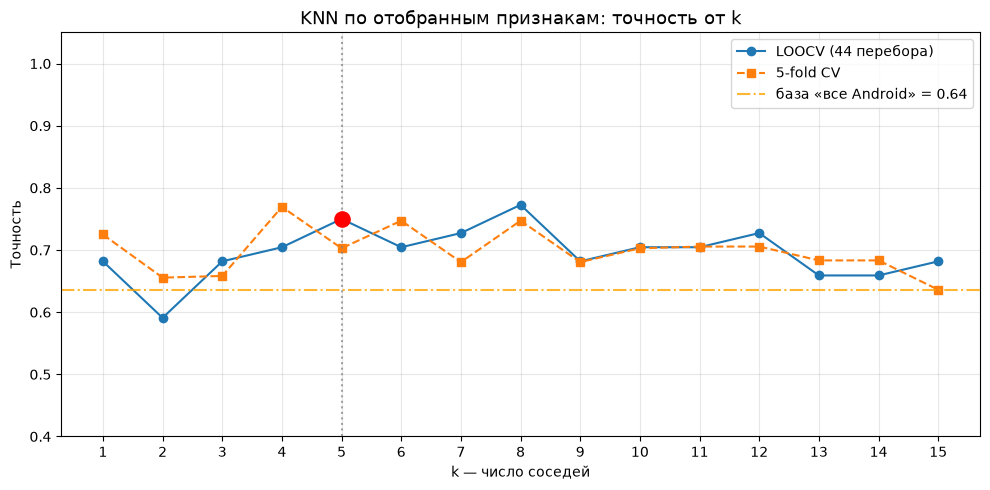

In [11]:
best_k_red, max_acc_red = pick_best(res_red)
hits_red = int(round(max_acc_red * len(y)))
bt_red = stats.binomtest(hits_red, len(y), base, alternative='greater')
print(f'Лучшая LOO-точность: {max_acc_red:.3f}  ({hits_red}/{len(y)})')
print(f'Биномиальный тест против базы ({base:.3f}): p = {bt_red.pvalue:.3f}')
print(f'Выбираем k = {best_k_red}')

plt.figure(figsize=(10, 5))
plt.plot(res_red['k'], res_red['loo_acc'], 'o-', label='LOOCV (44 перебора)')
plt.plot(res_red['k'], res_red['cv5_acc'], 's--', label='5-fold CV')
plt.axhline(base, color='orange', ls='-.', alpha=.8, label=f'база «все Android» = {base:.2f}')
plt.axvline(best_k_red, color='gray', ls=':', alpha=.7)
plt.scatter([best_k_red], [float(res_red.loc[res_red['k'] == best_k_red, 'loo_acc'].iloc[0])],
            s=120, zorder=5, color='red')
plt.xlabel('k — число соседей')
plt.ylabel('Точность')
plt.title('KNN по отобранным признакам: точность от k')
plt.xticks(ks)
plt.ylim(0.4, 1.05)
plt.grid(alpha=.3)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Итоговая модель и тестирование

Разбиение train/test 80/20 (стратифицированное, seed = 42), k — выбранный в разделе 5, признаки — отобранные. Тестовая часть мала (9 записей), поэтому **главная оценка качества — LOOCV** (раздел 5); тест-сплит показывает работу на «новых» людях.

Оговорка: признаки отбирались на тех же данных, что и LOO, поэтому 0.77 — слегка оптимистичная оценка. Честная проверка требует новой выборки (ещё анкет).

k = 5 | тест: 9 из 44 записей
Accuracy: 0.556   (база: 0.636)

              precision    recall  f1-score   support

     Андроид       0.75      0.50      0.60         6
       Айфон       0.40      0.67      0.50         3

    accuracy                           0.56         9
   macro avg       0.57      0.58      0.55         9
weighted avg       0.63      0.56      0.57         9



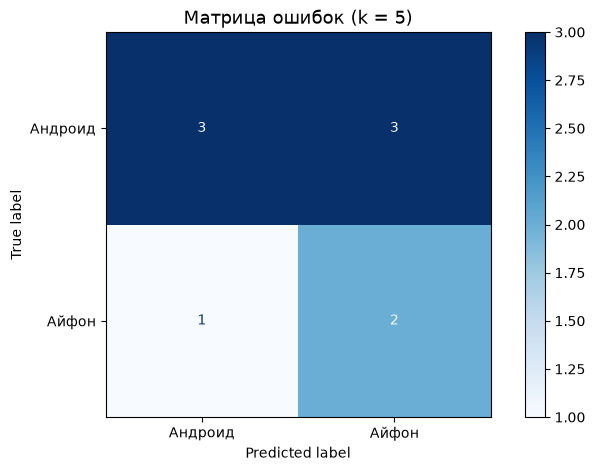

In [12]:
X_tr, X_te, y_tr, y_te = train_test_split(X_red, y, test_size=0.2, stratify=y, random_state=SEED)
model = KNeighborsClassifier(n_neighbors=best_k_red)
model.fit(X_tr, y_tr)
pred = model.predict(X_te)

labels = ['Андроид', 'Айфон']
print(f'k = {best_k_red} | тест: {len(y_te)} из {len(y)} записей')
print(f'Accuracy: {accuracy_score(y_te, pred):.3f}   (база: {base:.3f})')
print()
print(classification_report(y_te, pred, target_names=labels, zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred, labels=[0, 1]),
                       display_labels=labels).plot(cmap='Blues')
plt.title(f'Матрица ошибок (k = {best_k_red})')
plt.show()

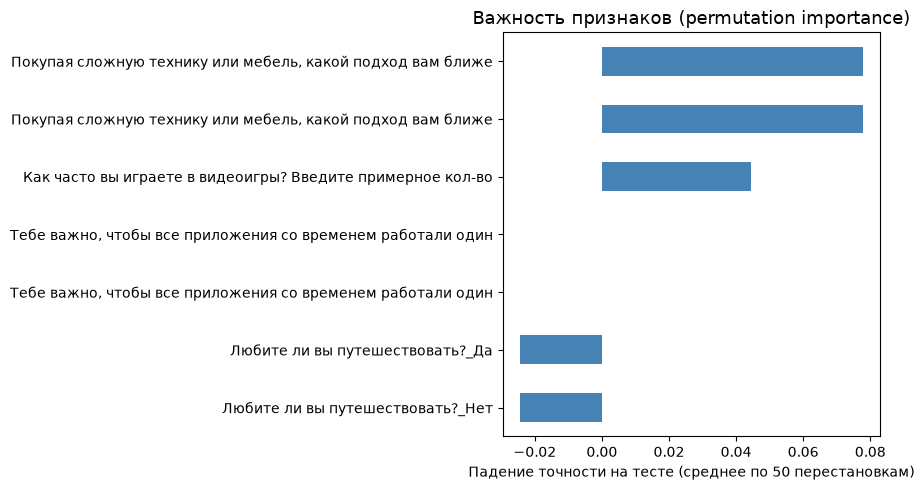

In [13]:
perm = permutation_importance(model, X_te, y_te, n_repeats=50, random_state=SEED)
names = list(ohe_red.get_feature_names_out(sel_cats)) + sel_nums
imp = (pd.Series(perm.importances_mean, index=names)
       .sort_values(ascending=True))
imp_disp = imp.copy()
imp_disp.index = [s[:58] for s in imp_disp.index]

plt.figure(figsize=(9, 5))
imp_disp.plot.barh(color='steelblue')
plt.xlabel('Падение точности на тесте (среднее по 50 перестановкам)')
plt.title('Важность признаков (permutation importance)')
plt.tight_layout()
plt.show()

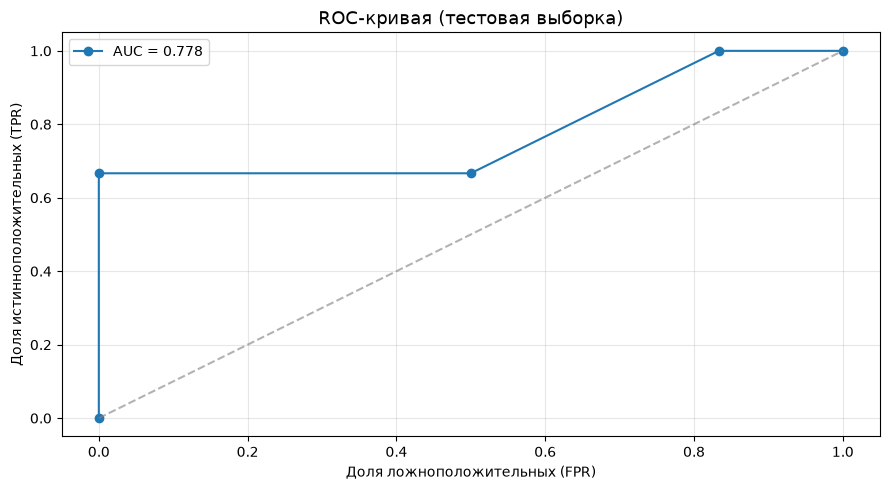

In [14]:
fpr, tpr, _ = roc_curve(y_te, model.predict_proba(X_te)[:, 1])
plt.plot(fpr, tpr, marker='o', label=f'AUC = {auc(fpr, tpr):.3f}')
plt.plot([0, 1], ls='--', c='gray', alpha=.6)
plt.xlabel('Доля ложноположительных (FPR)')
plt.ylabel('Доля истинноположительных (TPR)')
plt.title('ROC-кривая (тестовая выборка)')
plt.grid(alpha=.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Выводы

**Ответ на главный вопрос задания — какое k лучше:**

- Малое k (1–3) неустойчиво: по одному «соседу» решение слишком чувствительно к шуму (LOO 0.36–0.59 по всем признакам).
- Большое k (13–15) размывает различия между людьми и дрейфует к голосованию за большинство.
- **Оптимум — k ≈ 5–8**: соседей достаточно, чтобы сгладить шум, но они ещё «похожи» на данного человека. По правилу «наименьший стабильный k» (точность в пределах 3 п.п. от максимума) выбран **k = 5** (LOO 0.750), пик — k = 8 (LOO 0.773).

**Что показала модель:**

1. KNN по **всем** 26 признакам хуже тривиальной модели «все — Android» (0.614 против 0.636, p = 0.685) — проклятие размерности: при 44 образцах и 26 измерениях у KNN по факту нет близких соседей.
2. Единичный анализ нашёл информативные вопросы:
   - **часы видеоигр** (p = 0.049, связь −0.30: Android-пользователи играют больше);
   - **покупка сложной техники — «чтобы сразу работало из коробки»** (p = 0.084, +0.26 к iPhone);
   - **путешествия** (p = 0.110) и **«важно, чтобы приложения работали одинаково со временем»** (p = 0.125).
3. KNN по **4 отобранным признакам** (7 измерений): **LOO = 0.773** (34/44), значимо лучше базы (p = 0.039, 5%-уровень).

**Ограничения (честно):**
- n = 44 — маленькая выборка; тест-сплит из 9 записей не даёт надёжной оценки (accuracy 0.556 на тесте — шум, главное доказательство — LOO).
- Признаки отбирались на тех же данных, что и LOO, поэтому 0.77 — слегка оптимистичная оценка.
- Для честной проверки нужна новая независимая выборка анкет (например, ещё 30–50 человек).

**Итог:** ИИ научился различать iPhone/Android лучше случайного уровня (0.77 против базы 0.64 по LOOCV, k = 5–8); главный сигнал анкеты — игровые привычки и отношение к технике «из коробки».